# Residual Learning, Receptive Field e UNet

Questo notebook sviluppa i concetti successivi ad una semplice CNN per la ricostruzione di immagini. Si discute innanzitutto il **residual learning** e il motivo per cui apprendere l'artefatto è più semplice che apprendere direttamente l'immagine pulita. Si introduce poi il concetto di **receptive field** come criterio chiave di progettazione e si conclude con l'architettura **UNet**, spesso la scelta predefinita più efficace per la ricostruzione end-to-end.

Riferimento: [Residual Learning, Receptive Field, and UNet — Computational Imaging](https://devangelista2.github.io/computational-imaging/2025-26/end-to-end/residual-learning-and-unet.html)

---

## Motivazione del Residual Learning

Una CNN addestrata per elaborare immagini impara a riconoscere pattern nei dati di input. Tuttavia, se il modello è addestrato su immagini di gatti, non è detto che generalizzi bene su immagini di cani, poiché i pattern specifici del dataset sono diversi.

Un'osservazione fondamentale è che, mentre i pattern delle immagini originali dipendono dal dataset, gli **artefatti** (cioè la differenza tra immagine corrotta e immagine vera) tendono a mostrare pattern legati al **task** piuttosto che ai dati. Questo giustifica il fatto che apprendere il residuo sia generalmente più semplice e generalizzi meglio.

### Blocco 1 — Caricamento immagini, corruzione e visualizzazione dei residui

In questo primo blocco si eseguono le seguenti operazioni:
1. **Importazione delle librerie** necessarie (PyTorch, PIL, matplotlib, IPPy).
2. **Caricamento** di due immagini di test (`Mayo.png` e `GoPro.jpg`) dalla cartella `imgs`, convertite in scala di grigi e ridimensionate a 256×256 pixel.
3. **Normalizzazione** dei valori dei pixel nell'intervallo [0, 1].
4. **Visualizzazione** delle immagini pulite.
5. **Applicazione di un operatore di blurring gaussiano** (kernel 3×3, varianza 1) e aggiunta di rumore gaussiano con livello 0.2 per corrompere le immagini.
6. **Visualizzazione** delle immagini corrotte.
7. **Calcolo e visualizzazione dei residui** $|y^\delta - x_{true}|$: si nota come i residui delle due immagini, pur provenendo da dataset diversi, presentino pattern visivamente simili — questo è il fondamento del residual learning.

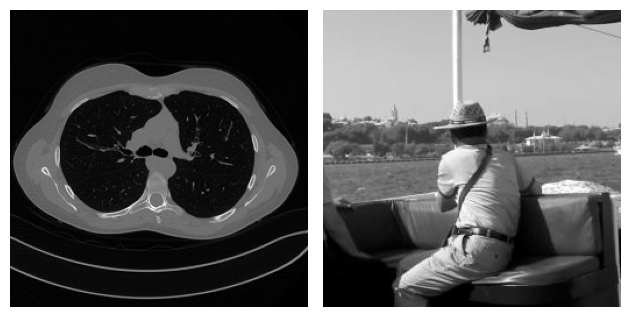

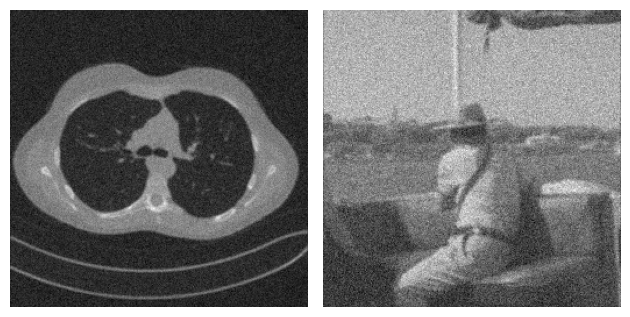

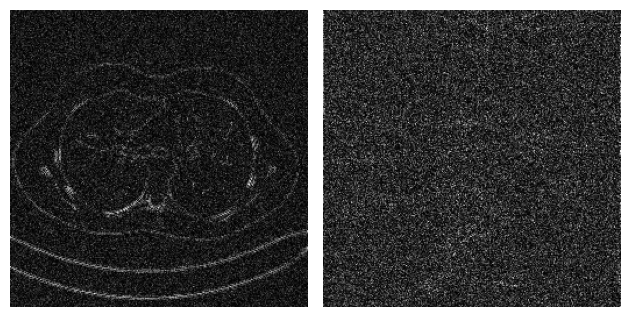

In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

sys.path.append('..')
from IPPy import operators, utilities

img_dir = Path('imgs')

# Load images explicitly from disk as grayscale arrays.
x_mayo = Image.open(img_dir / 'Mayo.png').convert('L')
x_mayo = torch.tensor(np.array(x_mayo), dtype=torch.float32).unsqueeze(0).unsqueeze(0)
x_mayo = F.interpolate(x_mayo, size=(256, 256), mode='bilinear', align_corners=False)
x_mayo = (x_mayo - x_mayo.min()) / (x_mayo.max() - x_mayo.min())

x_gopro = Image.open(img_dir / 'GoPro.jpg').convert('L')
x_gopro = torch.tensor(np.array(x_gopro), dtype=torch.float32).unsqueeze(0).unsqueeze(0)
x_gopro = F.interpolate(x_gopro, size=(256, 256), mode='bilinear', align_corners=False)
x_gopro = (x_gopro - x_gopro.min()) / (x_gopro.max() - x_gopro.min())

# Visualize the clean images.
plt.subplot(1, 2, 1)
plt.imshow(x_mayo.squeeze(), cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(x_gopro.squeeze(), cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

# Corrupt and add noise.
K = operators.Blurring(img_shape=(256, 256), kernel_type='gaussian', kernel_size=3, kernel_variance=1)

y_mayo = K(x_mayo)
y_mayo_delta = y_mayo + utilities.gaussian_noise(y_mayo, noise_level=0.2)

y_gopro = K(x_gopro)
y_gopro_delta = y_gopro + utilities.gaussian_noise(y_gopro, noise_level=0.2)

# Visualize the corrupted images.
plt.subplot(1, 2, 1)
plt.imshow(y_mayo_delta.squeeze(), cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(y_gopro_delta.squeeze(), cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

# Visualize the residuals.
plt.subplot(1, 2, 1)
plt.imshow(torch.abs(y_mayo_delta - x_mayo).squeeze(), cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(torch.abs(y_gopro_delta - x_gopro).squeeze(), cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

## Definizione della Residual CNN (ResCNN)

Sulla base dell'osservazione precedente, si introduce una variante della CNN in cui la rete non apprende direttamente l'immagine ricostruita, bensì il **residuo** (cioè la correzione da applicare all'input corrotto). L'output finale si ottiene sommando la predizione del residuo all'input stesso. Questa operazione prende il nome di **connessione residua** (*skip connection* o *residual connection*).

### Blocco 2 — Implementazione PyTorch della ResCNN

La classe `ResCNN` implementa una rete convoluzionale residua con la seguente struttura:
- **3 layer convoluzionali** con `padding="same"` (convoluzione con padding per mantenere le dimensioni spaziali).
- Le prime due convoluzioni sono seguite da attivazione **ReLU**, l'ultima da **Tanh** (per consentire output con valori negativi, utili per rappresentare il residuo).
- Nel metodo `forward`, il risultato della rete viene **sommato all'input `x`** (`return out + x`): questa è la connessione residua che distingue una ResCNN da una CNN standard.

In [7]:
import torch
from torch import nn

class ResCNN(nn.Module):
    def __init__(self, in_ch, out_ch, n_filters, kernel_size=3):
        super().__init__()

        # Define (convolution) layers -> NOTE: padding="same" means "padded convolution"
        self.conv1 = nn.Conv2d(in_channels=in_ch, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv2 = nn.Conv2d(in_channels=n_filters, out_channels=n_filters, kernel_size=kernel_size, padding="same")
        self.conv3 = nn.Conv2d(in_channels=n_filters, out_channels=out_ch, kernel_size=kernel_size, padding="same")

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        out = self.tanh(self.conv3(h))
        return out + x

## Addestramento della ResCNN sul dataset Mayo

Il training di un modello residuo segue la stessa logica di una CNN standard: la rete apprende una correzione che viene sommata all'input corrotto.

### Blocco 3 — Dataset, training loop, salvataggio pesi e valutazione

Questo blocco è piuttosto articolato e svolge le seguenti operazioni:

1. **Definizione del `MayoDataset`**: un dataset personalizzato che carica le immagini CT del dataset Mayo (suddivise in `train` e `test`), le converte in scala di grigi e le ridimensiona a 256×256.
2. **Configurazione del dispositivo** (`device`) tramite `utilities.get_device()` — seleziona automaticamente GPU se disponibile.
3. **Creazione dei DataLoader** per training e test con batch size 8.
4. **Definizione dell'operatore di corruzione `K`**: un blurring di tipo *motion* con kernel 9×9 e angolo 20°.
5. **Inizializzazione del modello `ResCNN`** con 32 filtri e kernel 3×3, ottimizzatore Adam (lr=1e-3) e loss MSE.
6. **Training loop per 20 epoche**: ad ogni step, le immagini pulite vengono corrotte on-the-fly con blurring + rumore gaussiano (livello 0.01), e la rete apprende a ricostruirle.
7. **Salvataggio dei pesi** in `weights/ResCNN.pth`.
8. **Ricaricamento del modello** dai pesi salvati e valutazione su un'immagine di test.
9. **Visualizzazione**: ground truth, misurazione corrotta, ricostruzione della ResCNN e curva di loss.

In [ ]:
import glob
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

sys.path.append('..')
from IPPy import operators, utilities

book_root = Path('').resolve()
weights_dir = book_root / 'weights'
weights_dir.mkdir(exist_ok=True)

class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape):
        super().__init__()
        self.data_path = data_path
        self.data_shape = data_shape
        self.fname_list = glob.glob(f'{data_path}/*/*.png')

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        img_path = self.fname_list[idx]
        x = Image.open(img_path).convert('L')
        x = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(self.data_shape),
        ])(x)
        return x

device = utilities.get_device()
train_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'train'), data_shape=256)
test_dataset = MayoDataset(data_path=str(book_root / 'Mayo' / 'test'), data_shape=256)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

K = operators.Blurring(
    img_shape=(256, 256),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=20,
)

torch.manual_seed(0)
model = ResCNN(in_ch=1, out_ch=1, n_filters=32, kernel_size=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_epochs = 20
noise_level = 0.01
history = []
weights_path = weights_dir / 'ResCNN.pth'

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', leave=True)

    for step, x_batch in enumerate(progress_bar, start=1):
        x_batch = x_batch.to(device)

        with torch.no_grad():
            y_batch = K(x_batch)
            y_batch = y_batch + utilities.gaussian_noise(y_batch, noise_level=noise_level)

        prediction = model(y_batch)
        loss = loss_fn(prediction, x_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(batch_loss=f'{loss.item():.6f}', avg_loss=f'{epoch_loss / step:.6f}')

    history.append(epoch_loss / len(train_loader))

torch.save(model.state_dict(), weights_path)
print(f'Saved ResCNN weights to: {weights_path}')

reloaded_model = ResCNN(in_ch=1, out_ch=1, n_filters=32, kernel_size=3)
reloaded_model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
reloaded_model = reloaded_model.to(device)
reloaded_model.eval()

with torch.no_grad():
    x_true = next(iter(test_loader))[0:1].to(device)
    y_delta = K(x_true)
    y_delta = y_delta + utilities.gaussian_noise(y_delta, noise_level=noise_level)
    x_rec = reloaded_model(y_delta)

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(x_true.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(y_delta.cpu().squeeze(), cmap='gray')
plt.title('Measurement')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(x_rec.cpu().squeeze(), cmap='gray')
plt.title('Reloaded ResCNN')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.plot(history)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Architettura UNet — Baseline

La UNet è un'architettura encoder-decoder multi-scala progettata per la ricostruzione di immagini. La sua forza risiede in tre elementi chiave:
1. **Receptive field ampio** grazie al downsampling progressivo nell'encoder.
2. **Preservazione dei dettagli fini** tramite le *skip connections* tra encoder e decoder alla stessa risoluzione.
3. **Raffinamento locale** tramite convoluzioni nel decoder.

### Blocco 4 — Blocchi fondamentali e SimpleUNet

In questo blocco vengono definiti i componenti base dell'architettura UNet e la funzione di training:

- **`DoubleConv`**: blocco convoluzionale standard con due convoluzioni 3×3 + ReLU.
- **`DownBlock`**: downsampling con MaxPool2d(2) seguito da un `DoubleConv`. Dimezza la risoluzione spaziale e aumenta i canali.
- **`UpBlock`**: upsampling con ConvTranspose2d (stride 2), concatenazione della skip connection dall'encoder, seguito da un `DoubleConv`.
- **`SimpleUNet`**: la UNet completa con 3 livelli di encoder, un bottleneck, 3 livelli di decoder e una convoluzione 1×1 finale.

Viene inoltre definita la funzione **`train_and_reload`** che:
- Addestra un modello generico per un certo numero di epoche con corruzione on-the-fly.
- Salva i pesi e li ricarica in un nuovo modello per la valutazione.

Infine il modello `SimpleUNet` viene addestrato per **10 epoche** e si visualizza la ricostruzione insieme alla curva di loss e al numero totale di parametri addestrabili.

In [ ]:
import torch.nn.functional as F
from tqdm.auto import tqdm

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, block_cls=DoubleConv):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.block = block_cls(in_ch, out_ch)

    def forward(self, x):
        return self.block(self.pool(x))


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, block_cls=DoubleConv):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.block = block_cls(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.block(x)


class SimpleUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base_ch)
        self.enc2 = DownBlock(base_ch, 2 * base_ch)
        self.enc3 = DownBlock(2 * base_ch, 4 * base_ch)
        self.bottleneck = DownBlock(4 * base_ch, 8 * base_ch)
        self.dec3 = UpBlock(8 * base_ch, 4 * base_ch, 4 * base_ch)
        self.dec2 = UpBlock(4 * base_ch, 2 * base_ch, 2 * base_ch)
        self.dec1 = UpBlock(2 * base_ch, base_ch, base_ch)
        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        h = self.bottleneck(s3)
        h = self.dec3(h, s3)
        h = self.dec2(h, s2)
        h = self.dec1(h, s1)
        return self.out_conv(h)


def train_and_reload(model, weights_path, num_epochs=20, noise_level=0.01, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', leave=True)

        for step, x_batch in enumerate(progress_bar, start=1):
            x_batch = x_batch.to(device)

            with torch.no_grad():
                y_batch = K(x_batch)
                y_batch = y_batch + utilities.gaussian_noise(y_batch, noise_level=noise_level)

            prediction = model(y_batch)
            loss = loss_fn(prediction, x_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            progress_bar.set_postfix(batch_loss=f'{loss.item():.6f}', avg_loss=f'{epoch_loss / step:.6f}')

        history.append(epoch_loss / len(train_loader))

    torch.save(model.state_dict(), weights_path)
    print(f'Saved weights to: {weights_path}')

    reloaded_model = type(model)()
    reloaded_model.load_state_dict(torch.load(weights_path, map_location='cpu', weights_only=True))
    reloaded_model = reloaded_model.to(device)
    reloaded_model.eval()
    return reloaded_model, history


torch.manual_seed(0)
unet_model, unet_history = train_and_reload(SimpleUNet(in_ch=1, out_ch=1, base_ch=32), weights_dir / 'UNet.pth', num_epochs=10)

with torch.no_grad():
    x_true = next(iter(test_loader))[0:1].to(device)
    y_delta = K(x_true)
    y_delta = y_delta + utilities.gaussian_noise(y_delta, noise_level=0.01)
    x_rec = unet_model(y_delta)

num_params = sum(p.numel() for p in unet_model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {num_params}')

plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(x_true.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(y_delta.cpu().squeeze(), cmap='gray')
plt.title('Measurement')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(x_rec.cpu().squeeze(), cmap='gray')
plt.title('Reloaded UNet')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.plot(unet_history)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Variante 1 — Residual UNet

La prima variante naturale della UNet è la **Residual UNet**. La motivazione è analoga a quella della ResCNN: invece di forzare ogni blocco ad apprendere una trasformazione completa da zero, si lascia che apprenda una **correzione attorno a una mappa identità**. Questo facilita l'ottimizzazione e aiuta la propagazione dei gradienti nelle reti più profonde.

Questa variante è particolarmente utile quando:
- La rete è profonda e difficile da addestrare.
- Il task è naturalmente formulato come rimozione di artefatti.
- Si vuole che la rete preservi le feature stabili e raffini solo ciò che deve essere corretto.

### Blocco 5 — `ResidualDoubleConv` e `ResidualUNet`

- **`ResidualDoubleConv`**: sostituisce il `DoubleConv` standard con un blocco residuo. L'input viene proiettato tramite una convoluzione 1×1 (se necessario per allineare i canali) e sommato all'output delle due convoluzioni.
- **`ResidualUNet`**: identica struttura encoder-decoder della `SimpleUNet`, ma tutti i blocchi convoluzionali sono di tipo `ResidualDoubleConv`.

Il modello viene addestrato per 10 epoche e si visualizza la curva di loss.

In [ ]:
class ResidualDoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.shortcut = nn.Conv2d(in_ch, out_ch, kernel_size=1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        h = self.relu(self.conv1(x))
        h = self.conv2(h)
        return self.relu(h + identity)


class ResidualUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        self.enc1 = ResidualDoubleConv(in_ch, base_ch)
        self.enc2 = DownBlock(base_ch, 2 * base_ch, block_cls=ResidualDoubleConv)
        self.enc3 = DownBlock(2 * base_ch, 4 * base_ch, block_cls=ResidualDoubleConv)
        self.bottleneck = DownBlock(4 * base_ch, 8 * base_ch, block_cls=ResidualDoubleConv)
        self.dec3 = UpBlock(8 * base_ch, 4 * base_ch, 4 * base_ch, block_cls=ResidualDoubleConv)
        self.dec2 = UpBlock(4 * base_ch, 2 * base_ch, 2 * base_ch, block_cls=ResidualDoubleConv)
        self.dec1 = UpBlock(2 * base_ch, base_ch, base_ch, block_cls=ResidualDoubleConv)
        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        h = self.bottleneck(s3)
        h = self.dec3(h, s3)
        h = self.dec2(h, s2)
        h = self.dec1(h, s1)
        return self.out_conv(h)


torch.manual_seed(0)
resunet_model, resunet_history = train_and_reload(ResidualUNet(in_ch=1, out_ch=1, base_ch=32), weights_dir / 'ResidualUNet.pth', num_epochs=10)

plt.figure(figsize=(5, 3))
plt.plot(resunet_history)
plt.title('Residual UNet training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)
plt.show()

## Variante 2 — Attention UNet

La seconda estensione è la **Attention UNet**. L'idea principale è quella di **modulare le skip connections**: invece di inoltrare tutte le feature dell'encoder invariate, la rete apprende dei *gate* che enfatizzano le feature più rilevanti per lo stato corrente del decoder.

A differenza del caso residuo, qui il problema non è tanto l'ottimizzazione, quanto la **selezione delle feature**. In una UNet standard, ogni skip connection inoltra una grande quantità di informazione, compresi segnali poco informativi. I gate di attenzione filtrano queste feature, evidenziando le strutture spaziali più importanti per la ricostruzione.

### Blocco 6 — `AttentionGate`, `AttentionUpBlock` e `AttentionUNet`

- **`AttentionGate`**: prende in input il segnale del *gate* (proveniente dal decoder) e lo *skip* (dall'encoder). Entrambi vengono proiettati in uno spazio intermedio, sommati, passati per ReLU e poi per una convoluzione 1×1 + Sigmoid che produce il coefficiente di attenzione α ∈ [0,1]. Lo skip viene moltiplicato per α.
- **`AttentionUpBlock`**: blocco di upsampling con gate di attenzione prima della concatenazione.
- **`AttentionUNet`**: stessa struttura encoder della SimpleUNet, ma i blocchi di decoder sono `AttentionUpBlock`.

Il modello viene addestrato per 10 epoche e si visualizza la curva di loss.

In [ ]:
class AttentionGate(nn.Module):
    def __init__(self, gate_ch, skip_ch, inter_ch):
        super().__init__()
        self.gate_proj = nn.Conv2d(gate_ch, inter_ch, kernel_size=1)
        self.skip_proj = nn.Conv2d(skip_ch, inter_ch, kernel_size=1)
        self.psi = nn.Conv2d(inter_ch, 1, kernel_size=1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, gate, skip):
        a = self.gate_proj(gate)
        b = self.skip_proj(skip)
        if a.shape[-2:] != b.shape[-2:]:
            a = F.interpolate(a, size=b.shape[-2:], mode='bilinear', align_corners=False)
        alpha = self.sigmoid(self.psi(self.relu(a + b)))
        return skip * alpha


class AttentionUpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.attn = AttentionGate(out_ch, skip_ch, out_ch)
        self.block = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        skip = self.attn(x, skip)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.block(x)


class AttentionUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base_ch)
        self.enc2 = DownBlock(base_ch, 2 * base_ch)
        self.enc3 = DownBlock(2 * base_ch, 4 * base_ch)
        self.bottleneck = DownBlock(4 * base_ch, 8 * base_ch)
        self.dec3 = AttentionUpBlock(8 * base_ch, 4 * base_ch, 4 * base_ch)
        self.dec2 = AttentionUpBlock(4 * base_ch, 2 * base_ch, 2 * base_ch)
        self.dec1 = AttentionUpBlock(2 * base_ch, base_ch, base_ch)
        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        h = self.bottleneck(s3)
        h = self.dec3(h, s3)
        h = self.dec2(h, s2)
        h = self.dec1(h, s1)
        return self.out_conv(h)


torch.manual_seed(0)
attunet_model, attunet_history = train_and_reload(AttentionUNet(in_ch=1, out_ch=1, base_ch=32), weights_dir / 'AttentionUNet.pth', num_epochs=10)

plt.figure(figsize=(5, 3))
plt.plot(attunet_history)
plt.title('Attention UNet training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)
plt.show()

## Variante 3 — UNet++

La terza variante è **UNet++**. A differenza delle varianti precedenti, qui non si modificano i blocchi convoluzionali né i gate di attenzione, ma si riprogettano le **skip connections stesse**. L'idea è quella di inserire percorsi intermedi "annidati" (*nested skip pathways*) che riducono il divario semantico tra le feature dell'encoder e quelle del decoder.

In una UNet classica, le feature dell'encoder e del decoder alla stessa risoluzione vengono fuse direttamente, anche se possono rappresentare informazioni a livelli di astrazione molto diversi. UNet++ affronta questo problema inserendo raffinamenti convoluzionali intermedi lungo i percorsi skip.

### Blocco 7 — `UNetPP` (versione compatta a 3 livelli)

- **Encoder**: `x0_0`, `x1_0`, `x2_0` — tre livelli con downsampling via MaxPool.
- **Skip annidati**: `x0_1` combina `x0_0` con l'upsampling di `x1_0`; `x1_1` combina `x1_0` con l'upsampling di `x2_0`; `x0_2` combina `x0_0`, `x0_1` e l'upsampling di `x1_1` — creando una struttura densa.
- **Output**: una convoluzione 1×1 finale.

Il modello viene addestrato per 10 epoche e si visualizza la curva di loss.

In [ ]:
class UNetPP(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base_ch=32):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

        self.x0_0 = DoubleConv(in_ch, base_ch)
        self.x1_0 = DoubleConv(base_ch, 2 * base_ch)
        self.x2_0 = DoubleConv(2 * base_ch, 4 * base_ch)

        self.x0_1 = DoubleConv(base_ch + 2 * base_ch, base_ch)
        self.x1_1 = DoubleConv(2 * base_ch + 4 * base_ch, 2 * base_ch)
        self.x0_2 = DoubleConv(base_ch * 2 + 2 * base_ch, base_ch)

        self.out_conv = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    def forward(self, x):
        x0_0 = self.x0_0(x)
        x1_0 = self.x1_0(self.pool(x0_0))
        x2_0 = self.x2_0(self.pool(x1_0))

        x0_1 = self.x0_1(torch.cat([x0_0, self.up(x1_0)], dim=1))
        x1_1 = self.x1_1(torch.cat([x1_0, self.up(x2_0)], dim=1))
        x0_2 = self.x0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], dim=1))

        return self.out_conv(x0_2)


torch.manual_seed(0)
unetpp_model, unetpp_history = train_and_reload(UNetPP(in_ch=1, out_ch=1, base_ch=32), weights_dir / 'UNetPP.pth', num_epochs=10)

plt.figure(figsize=(5, 3))
plt.plot(unetpp_history)
plt.title('UNet++ training loss')
plt.xlabel('Epoch')
plt.grid(alpha=0.3)
plt.show()

## Confronto tra le varianti sulla stessa immagine corrotta

Per concludere la sezione, si ricostruisce la stessa immagine di test corrotta con tutte e quattro le architetture: **UNet**, **Residual UNet**, **Attention UNet** e **UNet++**.

### Blocco 8 — Confronto visivo e quantitativo

Questo confronto è fondamentale perché isola la scelta architetturale mantenendo fissa la corruzione dell'input. Le operazioni svolte sono:

1. **Corruzione** di un'immagine di test con l'operatore di blurring `K` + rumore gaussiano.
2. **Ricostruzione** con ciascuno dei 4 modelli addestrati.
3. **Visualizzazione** affiancata: ground truth, misurazione, UNet, Residual UNet, Attention UNet, UNet++.
4. **Calcolo del MSE** (Mean Squared Error) per ciascun modello rispetto al ground truth.

Lo scopo è verificare come piccole differenze nel design dei blocchi, nella selezione delle skip connection o nella fusione delle feature possano portare a comportamenti di ricostruzione visibilmente diversi, anche quando la struttura encoder-decoder complessiva rimane la stessa.

In [ ]:
torch.manual_seed(123)

with torch.no_grad():
    x_compare = test_dataset[0].unsqueeze(0).to(device)
    y_compare = K(x_compare)
    y_compare = y_compare + utilities.gaussian_noise(y_compare, noise_level=0.01)

    recon_plain = unet_model(y_compare)
    recon_residual = resunet_model(y_compare)
    recon_attention = attunet_model(y_compare)
    recon_pp = unetpp_model(y_compare)

plt.figure(figsize=(18, 4))
plt.subplot(1, 6, 1)
plt.imshow(x_compare.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 6, 2)
plt.imshow(y_compare.cpu().squeeze(), cmap='gray')
plt.title('Measurement')
plt.axis('off')

plt.subplot(1, 6, 3)
plt.imshow(recon_plain.cpu().squeeze(), cmap='gray')
plt.title('UNet')
plt.axis('off')

plt.subplot(1, 6, 4)
plt.imshow(recon_residual.cpu().squeeze(), cmap='gray')
plt.title('Residual UNet')
plt.axis('off')

plt.subplot(1, 6, 5)
plt.imshow(recon_attention.cpu().squeeze(), cmap='gray')
plt.title('Attention UNet')
plt.axis('off')

plt.subplot(1, 6, 6)
plt.imshow(recon_pp.cpu().squeeze(), cmap='gray')
plt.title('UNet++')
plt.axis('off')

plt.tight_layout()
plt.show()

for name, rec in [('UNet', recon_plain), ('Residual UNet', recon_residual), ('Attention UNet', recon_attention), ('UNet++', recon_pp)]:
    mse = torch.mean((rec - x_compare) ** 2).item()
    print(f'{name:>16} | MSE = {mse:.6f}')